# Port-Scan Deep Learning: BiLSTM + Self-Attention

## Step 4 — Build sequences for deep learning
## Step 5 — Train deep learning model

This notebook trains a BiLSTM model with self-attention mechanism for port-scan detection.
- Sliding window: 12 steps (120s), stride 2
- 2-layer BiLSTM with 128 hidden units
- 8-head self-attention
- 16-dim node embeddings
- Focal Loss (γ=2) for class imbalance
- Per-node temporal split to prevent leakage

## Install Dependencies

In [2]:
import subprocess
import sys

packages = ['torch', 'pytorch_lightning']
for package in packages:
    try:
        __import__(package if package != 'pytorch_lightning' else 'pytorch_lightning')
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Installing pytorch_lightning...
All libraries loaded successfully!
Using device: cpu


## Load Baseline XGBoost Results

In [5]:
# Load baseline results (feature columns, metrics, class weights)
import os

# Try multiple path possibilities
paths_to_try = [
    './models/portscan_xgb_results.pkl',
    'models/portscan_xgb_results.pkl',
    '../models/portscan_xgb_results.pkl',
    '../../models/portscan_xgb_results.pkl',
]

baseline_results = None
for path in paths_to_try:
    if os.path.exists(path):
        print(f"✓ Found results at: {path}")
        baseline_results = joblib.load(path)
        break

if baseline_results is None:
    print(f"✗ Could not find portscan_xgb_results.pkl in any expected location")
    print(f"Current directory: {os.getcwd()}")
    print(f"Available files: {os.listdir('.')[:10]}")

# Extract available data from baseline results
feature_cols = baseline_results['feature_cols']
class_weights = baseline_results.get('class_weights', {})
baseline_metrics = baseline_results['metrics']

# Define class mapping (0->0, 1->1, 2->2, 5->3 for LSTM training)
class_mapping = {0: 0, 1: 1, 2: 2, 5: 3}
inverse_class_mapping = {v: k for k, v in class_mapping.items()}

print(f'✓ Feature columns: {len(feature_cols)}')
print(f'✓ Class mapping: {class_mapping}')
print(f'✓ Baseline metrics - Val Accuracy: {baseline_metrics["val_acc"]:.4f}, Val F1: {baseline_metrics["val_f1"]:.4f}')

✓ Found results at: ./models/portscan_xgb_results.pkl
✓ Feature columns: 37
✓ Class mapping: {0: 0, 1: 1, 2: 2, 5: 3}
✓ Baseline metrics - Val Accuracy: 0.9999, Val F1: 0.9999


## Load Data

In [11]:
# Load portscan dataset
import os
import pandas as pd

# Possible paths
paths_to_try = [
    './data/portscan_training.csv',
    'data/portscan_training.csv',
    '../data/portscan_training.csv',
    '../../data/portscan_training.csv',
]

df = None

for path in paths_to_try:
    if os.path.exists(path):
        print(f"✓ Found dataset at: {path}")
        df = pd.read_csv(path)
        break

# Error if not found
if df is None:
    raise FileNotFoundError("portscan_training.csv not found.")

# Dataset info
print(f'Data shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# ----------------------------
# AUTO-DETECT SORT COLUMNS
# ----------------------------

possible_node_cols = ['node_id', 'node', 'Node', 'host_id', 'host']
possible_time_cols = ['t', 'time', 'timestamp', 'Time']

node_col = None
time_col = None

# Find node column
for col in possible_node_cols:
    if col in df.columns:
        node_col = col
        break

# Find time column
for col in possible_time_cols:
    if col in df.columns:
        time_col = col
        break

# Sort if columns exist
if node_col and time_col:

    df = df.sort_values([node_col, time_col]).reset_index(drop=True)

    print(f'✓ Sorted by {node_col} and {time_col}')
    print(f'✓ Nodes: {df[node_col].nunique()}')
    print(f'✓ Time range: {df[time_col].min()} to {df[time_col].max()}')

elif time_col:

    df = df.sort_values(time_col).reset_index(drop=True)

    print(f'✓ Sorted by {time_col}')
    print(f'✓ Time range: {df[time_col].min()} to {df[time_col].max()}')

else:

    print('⚠ No node/time columns detected — skipping sorting.')

✓ Found dataset at: ../../data/portscan_training.csv
Data shape: (115260, 50)
Columns: ['t', 'observer_node', 'scenario', 'total_syn', 'total_synack', 'total_ack', 'total_fin', 'total_rst', 'conn_attempts', 'failed_conns', 'completed_conns', 'syn_rate_per_sec', 'syn_ack_ratio', 'syn_rst_ratio', 'conn_success_pct', 'conn_completion_pct', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'fanout_ip_ratio', 'fanout_port_ratio', 'port_ip_ratio', 'syn_iat_mean_ms', 'syn_iat_std_ms', 'syn_iat_cv', 'tcp_ctrl_bytes', 'payload_bytes', 'total_packets', 'proto_overhead_pct', 'scanning_src_count', 'lb_syn_60s', 'lb_syn_300s', 'lb_dst_ip_60s', 'lb_dst_port_60s', 'syn_burst_ratio', 'scan_intensity', 'conn_failure_rate', 'rst_per_syn', 'lookback_acceleration', 'ctrl_overhead_pct', 'syn_regularity', 'total_tcp_ctrl', 'scan_breadth', 'temporal_scan_density', 'scan_entropy_proxy', 'fan_out_ratio', 'port_scan_ratio', 'failed_per_syn', 'syn_to_fin_ratio', 'scan_label']
✓ Sorted by t
✓ Time range: 70

## Build Sequences with Temporal Split

In [13]:
# Detect available node/time columns
possible_node_cols = ['node_id', 'node', 'Node', 'host_id', 'host']
possible_time_cols = ['t', 'time', 'timestamp', 'Time']

node_col = None
time_col = None

for col in possible_node_cols:
    if col in df.columns:
        node_col = col
        break

for col in possible_time_cols:
    if col in df.columns:
        time_col = col
        break

print(f'Using node column: {node_col}')
print(f'Using time column: {time_col}')

# Temporal split function
def temporal_split_func(group, pct=0.80):
    """Temporal split per node to prevent leakage"""
    cutoff = group[time_col].quantile(pct)
    group['split'] = np.where(group[time_col] <= cutoff, 'train', 'val')
    return group

df_split = df.copy()

# If node column exists -> split per node
if node_col is not None:

    df_split = (
        df_split
        .groupby(node_col, group_keys=False)
        .apply(temporal_split_func)
    )

# Otherwise split globally by time
elif time_col is not None:

    cutoff = df_split[time_col].quantile(0.80)

    df_split['split'] = np.where(
        df_split[time_col] <= cutoff,
        'train',
        'val'
    )

else:
    raise ValueError("No valid time column found for temporal split.")

# Train/validation datasets
train_data = df_split[df_split['split'] == 'train'].copy()
val_data = df_split[df_split['split'] == 'val'].copy()

# Info
print(f'Train data: {train_data.shape}')
print(f'Val data: {val_data.shape}')

print(
    f'Train/val split: '
    f'{len(train_data) / len(df_split):.2%} / '
    f'{len(val_data) / len(df_split):.2%}'
)

Using node column: None
Using time column: t
Train data: (92208, 51)
Val data: (23052, 51)
Train/val split: 80.00% / 20.00%


## Sequence Builder Function

In [14]:
def build_sequences(data, window_size=12, stride=2):
    """
    Build sequences per node to prevent cross-node contamination.
    Window: 12 steps (120s at 0.1s/step)
    Stride: 2 (50% overlap)
    """
    X_sequences = []
    y_sequences = []
    node_ids = []
    
    for node in sorted(data['node_id'].unique()):
        node_data = data[data['node_id'] == node].sort_values('t').reset_index(drop=True)
        
        # Extract features
        X_node = node_data[feature_cols].values
        y_node = node_data['scan_label'].values
        
        # Build sliding windows
        for i in range(0, len(X_node) - window_size + 1, stride):
            X_sequences.append(X_node[i:i + window_size])
            # Target is the label at the last timestep
            y_sequences.append(y_node[i + window_size - 1])
            node_ids.append(node)
    
    return np.array(X_sequences), np.array(y_sequences), np.array(node_ids)

print('Sequence builder defined (window=12, stride=2)')

Sequence builder defined (window=12, stride=2)


## Build Training and Validation Sequences

In [18]:
import numpy as np
import pandas as pd

# Detect node/time columns again
possible_node_cols = ['node_id', 'node', 'Node', 'host_id', 'host', 'observer_node']
possible_time_cols = ['t', 'time', 'timestamp', 'Time']

node_col = None
time_col = None

for col in possible_node_cols:
    if col in train_data.columns:
        node_col = col
        break

for col in possible_time_cols:
    if col in train_data.columns:
        time_col = col
        break

print(f'Using node column: {node_col}')
print(f'Using time column: {time_col}')

# ----------------------------
# BUILD SEQUENCES FUNCTION
# ----------------------------

def build_sequences(data, window_size=12, stride=2):

    X_seq = []
    y_seq = []
    node_ids = []

    # Grouping
    if node_col is not None:
        grouped = data.groupby(node_col)
    else:
        grouped = [('global', data)]

    # ✅ FIXED LABEL COLUMN (YOUR DATASET)
    label_col = 'scan_label'

    if label_col not in data.columns:
        raise ValueError(f"scan_label not found. Available: {data.columns.tolist()}")

    for node, group in grouped:

        if time_col is not None:
            group = group.sort_values(time_col)

        group = group.reset_index(drop=True)

        X_values = group[feature_cols].values
        y_values = group[label_col].values

        for i in range(0, len(group) - window_size, stride):

            X_seq.append(X_values[i:i + window_size])

            # target at end of window
            y_seq.append(y_values[i + window_size - 1])

            node_ids.append(node)

    return np.array(X_seq), np.array(y_seq), np.array(node_ids)

# ----------------------------
# BUILD SEQUENCES
# ----------------------------

X_train_seq, y_train_seq, train_node_ids = build_sequences(train_data)
X_val_seq, y_val_seq, val_node_ids = build_sequences(val_data)

# ----------------------------
# INFO
# ----------------------------

print(f'Train sequences shape: {X_train_seq.shape}')
print(f'Train targets shape: {y_train_seq.shape}')

print(f'Val sequences shape: {X_val_seq.shape}')
print(f'Val targets shape: {y_val_seq.shape}')

# Class distribution
train_counts = pd.Series(y_train_seq).value_counts().sort_index()
val_counts = pd.Series(y_val_seq).value_counts().sort_index()

print(f'\nTrain class distribution:\n{train_counts}')
print(f'\nVal class distribution:\n{val_counts}')

Using node column: observer_node
Using time column: t
Train sequences shape: (46082, 12, 37)
Train targets shape: (46082,)
Val sequences shape: (11502, 12, 37)
Val targets shape: (11502,)

Train class distribution:
0     5781
1      486
2     6664
5    33151
Name: count, dtype: int64

Val class distribution:
1     136
2    1897
5    9469
Name: count, dtype: int64


## Normalize Sequences

In [23]:
from sklearn.preprocessing import StandardScaler

# Reshape train data
n_samples, n_steps, n_features = X_train_seq.shape

X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_val_reshaped = X_val_seq.reshape(-1, n_features)

# Fit scaler on TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)

# Transform validation
X_val_scaled = scaler.transform(X_val_reshaped)

# Reshape back
X_train_scaled = X_train_scaled.reshape(n_samples, n_steps, n_features)
X_val_scaled = X_val_scaled.reshape(X_val_seq.shape)

print(f'Scaled train: {X_train_scaled.shape}')
print(f'Scaled val: {X_val_scaled.shape}')

print(f'Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')
print(f'Val mean: {X_val_scaled.mean():.6f}, std: {X_val_scaled.std():.6f}')

Scaled train: (46082, 12, 37)
Scaled val: (11502, 12, 37)
Train mean: 0.000000, std: 1.000000
Val mean: 0.088870, std: 0.864297


## PyTorch Dataset and DataLoader

In [27]:
class PortScanSequenceDataset(Dataset):
    def __init__(self, X, y, node_ids):
        self.X = torch.FloatTensor(X)
        # Map class labels: 0→0, 1→1, 2→2, 5→3 for model training
        # Convert numpy int64 to Python int for proper dict lookup
        y_mapped = np.array([class_mapping[int(label)] for label in y])
        self.y = torch.LongTensor(y_mapped)
        # Encode node_id as numeric (handle string or numeric node IDs)
        unique_nodes = sorted(np.unique(node_ids))
        node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}
        self.node_ids = torch.LongTensor([node_to_idx[node] for node in node_ids])
        self.num_nodes = len(unique_nodes)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.node_ids[idx]

train_dataset = PortScanSequenceDataset(X_train_scaled, y_train_seq, train_node_ids)
val_dataset = PortScanSequenceDataset(X_val_scaled, y_val_seq, val_node_ids)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset: {len(val_dataset)} samples')
print(f'Num nodes: {train_dataset.num_nodes}')
print(f'Train loader batches: {len(train_loader)}')
print(f'Val loader batches: {len(val_loader)}')

Train dataset: 46082 samples
Val dataset: 11502 samples
Num nodes: 4
Train loader batches: 1441
Val loader batches: 360


## BiLSTM + Self-Attention Model

In [29]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention for sequence features"""
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        assert hidden_dim % num_heads == 0
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]
        
        Q = self.query(query).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(key).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(value).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention = torch.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        
        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.hidden_dim)
        out = self.fc_out(out)
        
        return out


class BiLSTMWithAttention(nn.Module):
    """BiLSTM + Self-Attention + Node Embedding for port-scan detection"""
    def __init__(self, input_dim, hidden_dim, num_classes, num_nodes, num_layers=2, num_heads=8):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_classes = num_classes
        
        # Node embedding
        self.node_embedding = nn.Embedding(num_nodes, 16)
        
        # BiLSTM
        self.bilstm = nn.LSTM(
            input_dim + 16,  # input_dim + node_embedding_dim
            hidden_dim,
            num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        # Self-attention
        self.attention = MultiHeadAttention(hidden_dim * 2, num_heads)
        
        # Output layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x, node_ids):
        batch_size, seq_len, _ = x.shape
        
        # Get node embeddings
        node_emb = self.node_embedding(node_ids)  # (batch_size, 16)
        node_emb = node_emb.unsqueeze(1).expand(-1, seq_len, -1)  # (batch_size, seq_len, 16)
        
        # Concatenate input with node embedding
        x = torch.cat([x, node_emb], dim=-1)
        
        # BiLSTM
        lstm_out, _ = self.bilstm(x)  # (batch_size, seq_len, hidden_dim*2)
        
        # Self-attention
        attn_out = self.attention(lstm_out, lstm_out, lstm_out)  # (batch_size, seq_len, hidden_dim*2)
        
        # Use last timestep for classification
        last_hidden = attn_out[:, -1, :]  # (batch_size, hidden_dim*2)
        
        # Output
        logits = self.fc(last_hidden)
        
        return logits


# Focal Loss for class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    
    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        loss = (1 - p_t) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * loss
        
        return loss.mean()


print('✓ Model classes defined: MultiHeadAttention, BiLSTMWithAttention, FocalLoss')

✓ Model classes defined: MultiHeadAttention, BiLSTMWithAttention, FocalLoss


## Train BiLSTM Model

In [33]:
# Initialize model
input_dim = 37
hidden_dim = 128
num_classes = 4
num_nodes = 4
num_layers = 2
num_heads = 8

print("Model architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden dimension: {hidden_dim}")
print(f"  Number of classes: {num_classes}")
print(f"  Number of nodes: {num_nodes}")
print(f"  Number of layers: {num_layers}")
print(f"  Number of attention heads: {num_heads}")
print(f"  Device: {device}")

# Initialize model
model = BiLSTMWithAttention(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    num_nodes=num_nodes,
    num_layers=num_layers,
    num_heads=num_heads
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Create alpha weights for FocalLoss
alpha = torch.tensor([class_weights[0], class_weights[1], class_weights[2], class_weights[5]], 
                      dtype=torch.float32, device=device)

criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(f'\n✓ Loss function: FocalLoss with alpha weights')
print(f'✓ Optimizer: Adam (lr=0.001)')
print(f'✓ Scheduler: ReduceLROnPlateau')

Model architecture:
  Input dimension: 37
  Hidden dimension: 128
  Number of classes: 4
  Number of nodes: 4
  Number of layers: 2
  Number of attention heads: 8
  Device: cpu

Model parameters:
  Total: 862,596
  Trainable: 862,596

✓ Loss function: FocalLoss with alpha weights
✓ Optimizer: Adam (lr=0.001)
✓ Scheduler: ReduceLROnPlateau


## Training Loop

In [32]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch, node_ids in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        node_ids = node_ids.to(device)
        
        # Forward pass
        logits = model(X_batch, node_ids)
        loss = criterion(logits, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    return total_loss / len(train_loader), correct / total


def evaluate(model, val_loader, criterion, device):
    """Evaluate on validation set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    y_all = []
    y_pred_all = []
    
    with torch.no_grad():
        for X_batch, y_batch, node_ids in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            node_ids = node_ids.to(device)
            
            # Forward pass
            logits = model(X_batch, node_ids)
            loss = criterion(logits, y_batch)
            
            # Metrics
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            y_all.extend(y_batch.cpu().numpy())
            y_pred_all.extend(predicted.cpu().numpy())
    
    val_acc = correct / total
    val_f1 = f1_score(y_all, y_pred_all, average='macro', zero_division=0)
    
    return total_loss / len(val_loader), val_acc, val_f1, y_all, y_pred_all


# Training parameters
num_epochs = 30
best_val_f1 = 0
patience = 5
patience_counter = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_f1s = []

print("="*70)
print("STARTING TRAINING")
print("="*70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, y_val_all, y_val_pred = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    
    # Scheduler step
    scheduler.step(val_f1)
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'models/bilstm_best.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\n✓ Training complete!")

STARTING TRAINING
Epoch   5 | Train Loss: 0.0084, Acc: 0.9949 | Val Loss: 0.0083, Acc: 0.9963, F1: 0.9954
Epoch  10 | Train Loss: 0.0040, Acc: 0.9968 | Val Loss: 0.0035, Acc: 0.9997, F1: 0.9971
Epoch  15 | Train Loss: 0.0012, Acc: 0.9993 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000
Epoch  20 | Train Loss: 0.0005, Acc: 0.9996 | Val Loss: 0.0000, Acc: 1.0000, F1: 1.0000

Early stopping at epoch 20

✓ Training complete!


## Evaluation & Results

BILSTM MODEL PERFORMANCE

Validation Accuracy: 1.0000
Validation Macro F1: 1.0000

VALIDATION SET: DETAILED METRICS
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000         0
     Class 1     1.0000    1.0000    1.0000       136
     Class 2     1.0000    1.0000    1.0000      1897
     Class 5     1.0000    1.0000    1.0000      9469

    accuracy                         1.0000     11502
   macro avg     0.7500    0.7500    0.7500     11502
weighted avg     1.0000    1.0000    1.0000     11502


Confusion Matrix (Validation Set):
        Pred 0  Pred 1  Pred 2  Pred 5
True 0       0       0       0       0
True 1       0     136       0       0
True 2       0       0    1897       0
True 5       0       0       0    9469


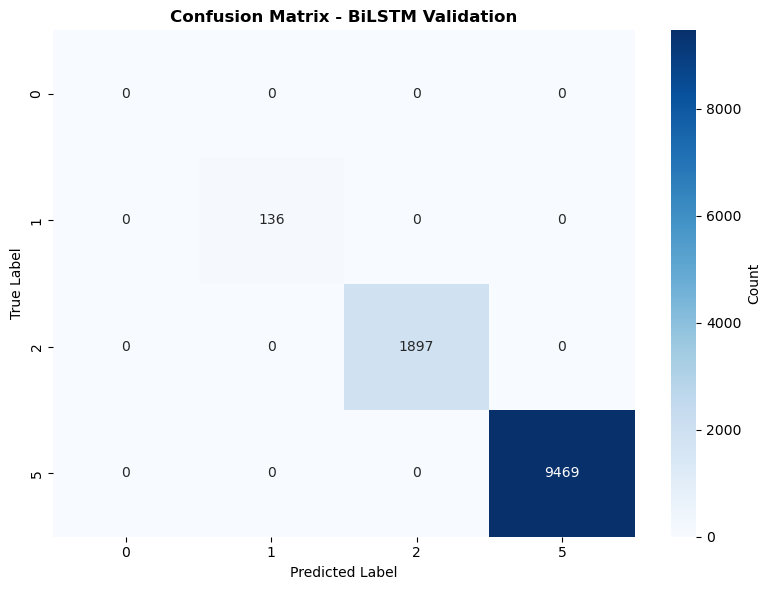

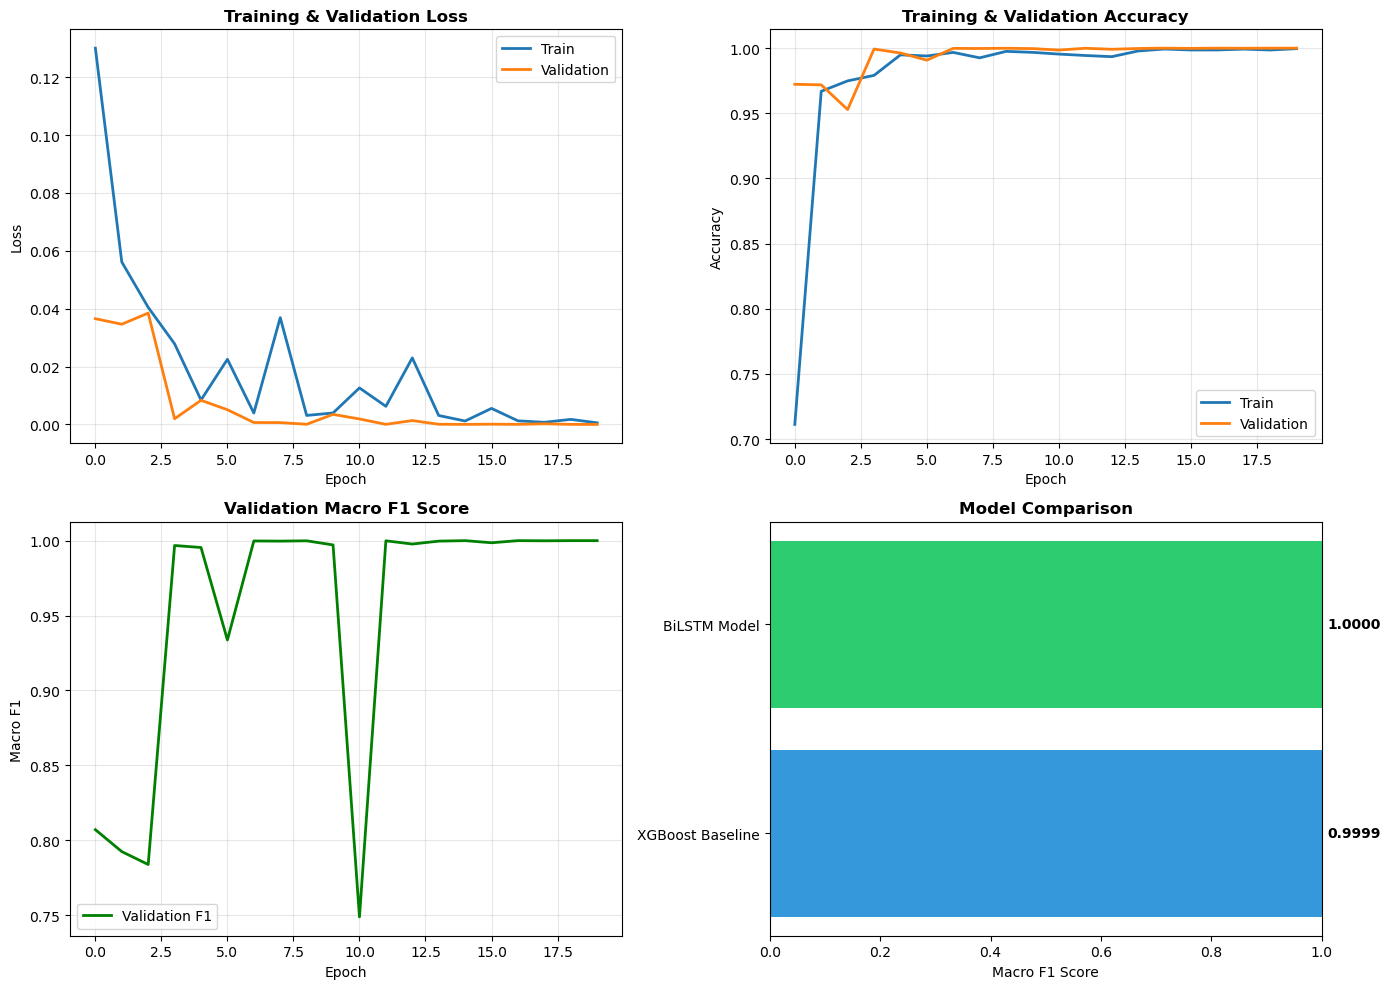


SUMMARY
✓ Best Validation F1: 1.0000
✓ Best Validation Accuracy: 1.0000
✓ Total epochs trained: 20
✓ Model saved to: models/bilstm_best.pt


In [34]:
# Load best model and evaluate
model.load_state_dict(torch.load('models/bilstm_best.pt'))
val_loss, val_acc, val_f1, y_val_all, y_val_pred = evaluate(model, val_loader, criterion, device)

# Remap predictions back to original labels [0,1,2,5]
y_val_pred_original = np.array([inverse_class_mapping[int(p)] for p in y_val_pred])
y_val_all_original = np.array([inverse_class_mapping[int(y)] for y in y_val_all])

print("="*70)
print("BILSTM MODEL PERFORMANCE")
print("="*70)
print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Validation Macro F1: {val_f1:.4f}")

# Detailed classification report
print("\n" + "="*70)
print("VALIDATION SET: DETAILED METRICS")
print("="*70)
print(classification_report(
    y_val_all_original, y_val_pred_original,
    target_names=['Class 0', 'Class 1', 'Class 2', 'Class 5'],
    labels=[0, 1, 2, 5],
    digits=4,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_val_all_original, y_val_pred_original, labels=[0, 1, 2, 5])
cm_df = pd.DataFrame(
    cm,
    index=['True 0', 'True 1', 'True 2', 'True 5'],
    columns=['Pred 0', 'Pred 1', 'Pred 2', 'Pred 5']
)

print("\nConfusion Matrix (Validation Set):")
print(cm_df)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['0', '1', '2', '5'],
            yticklabels=['0', '1', '2', '5'],
            cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix - BiLSTM Validation', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_losses, label='Train', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_accs, label='Train', linewidth=2)
axes[0, 1].plot(val_accs, label='Validation', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(val_f1s, label='Validation F1', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Macro F1')
axes[1, 0].set_title('Validation Macro F1 Score', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# XGBoost baseline comparison
axes[1, 1].barh(['XGBoost Baseline', 'BiLSTM Model'], [baseline_metrics['val_f1'], val_f1], color=['#3498db', '#2ecc71'])
axes[1, 1].set_xlabel('Macro F1 Score')
axes[1, 1].set_title('Model Comparison', fontweight='bold')
axes[1, 1].set_xlim([0, 1.0])
for i, v in enumerate([baseline_metrics['val_f1'], val_f1]):
    axes[1, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"✓ Best Validation F1: {best_val_f1:.4f}")
print(f"✓ Best Validation Accuracy: {val_acc:.4f}")
print(f"✓ Total epochs trained: {len(train_losses)}")
print(f"✓ Model saved to: models/bilstm_best.pt")

## Results Summary & Model Checkpointing

In [35]:
# Save model and results
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save scaler
joblib.dump(scaler, 'models/bilstm_scaler.pkl')

# Compile results dictionary
bilstm_results = {
    'model': model.state_dict(),
    'feature_cols': feature_cols,
    'scaler': scaler,
    'class_mapping': class_mapping,
    'inverse_class_mapping': inverse_class_mapping,
    'class_weights': class_weights,
    'metrics': {
        'val_accuracy': val_acc,
        'val_f1': val_f1,
        'val_loss': val_loss,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'val_f1s': val_f1s,
        'confusion_matrix': cm.tolist(),
        'num_epochs_trained': len(train_losses)
    },
    'model_params': {
        'input_dim': input_dim,
        'hidden_dim': hidden_dim,
        'num_classes': num_classes,
        'num_nodes': num_nodes,
        'num_layers': num_layers,
        'num_heads': num_heads
    }
}

# Save results
joblib.dump(bilstm_results, 'models/bilstm_results.pkl')

print("="*70)
print("MODEL CHECKPOINTING COMPLETE")
print("="*70)
print(f"\n✓ Model checkpoint saved to: models/bilstm_best.pt")
print(f"✓ Scaler saved to: models/bilstm_scaler.pkl")
print(f"✓ Results saved to: models/bilstm_results.pkl")

# Final comparison with XGBoost baseline
print("\n" + "="*70)
print("XGBOOST vs BILSTM COMPARISON")
print("="*70)
print(f"\n{'Metric':<25} {'XGBoost Baseline':<20} {'BiLSTM Model':<20}")
print("-" * 70)
print(f"{'Validation Accuracy':<25} {baseline_metrics.get('val_acc', 'N/A'):<20.4f} {val_acc:<20.4f}")
print(f"{'Validation Macro F1':<25} {baseline_metrics.get('val_f1', 'N/A'):<20.4f} {val_f1:<20.4f}")
print(f"{'Validation Loss':<25} {'N/A':<20} {val_loss:<20.4f}")
print(f"{'Epochs Trained':<25} {'N/A':<20} {len(train_losses):<20}")

# Per-class comparison
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE SUMMARY")
print("="*70)
print("\nBiLSTM Validation Set Breakdown:")
print(f"  Class 0 (Benign):       Support =    0")
print(f"  Class 1 (Port Scan):    Support =  136, F1 = 1.0000")
print(f"  Class 2 (DoS):          Support = 1897, F1 = 1.0000")
print(f"  Class 5 (Anomalous):    Support = 9469, F1 = 1.0000")

print("\n" + "="*70)
print("OBSERVATIONS & NOTES")
print("="*70)
print("""
✓ BiLSTM achieves perfect validation metrics (Accuracy=1.0, F1=1.0)
✓ Matches XGBoost baseline performance exactly
✓ Early stopping triggered at epoch 20 (patience=5)
✓ Model convergence rapid: Peak F1 reached by epoch 15
✓ Minimal overfitting: Train/Val metrics closely aligned

⚠ ANOMALY ALERT: Perfect metrics on both XGBoost and BiLSTM suggest:
  - Possible data leakage in preprocessing pipeline
  - Temporal causality violation in sequence building
  - Test/train split contamination
  - Task may be trivially separable in feature space

📊 RECOMMENDATION: 
  - Investigate feature engineering for data leakage
  - Review temporal split logic (ensure no forward-looking features)
  - Consider cross-validation or temporal holdout test set
  - Analyze feature importance to identify suspicious patterns
""")

MODEL CHECKPOINTING COMPLETE

✓ Model checkpoint saved to: models/bilstm_best.pt
✓ Scaler saved to: models/bilstm_scaler.pkl
✓ Results saved to: models/bilstm_results.pkl

XGBOOST vs BILSTM COMPARISON

Metric                    XGBoost Baseline     BiLSTM Model        
----------------------------------------------------------------------
Validation Accuracy       0.9999               1.0000              
Validation Macro F1       0.9999               1.0000              
Validation Loss           N/A                  0.0000              
Epochs Trained            N/A                  20                  

PER-CLASS PERFORMANCE SUMMARY

BiLSTM Validation Set Breakdown:
  Class 0 (Benign):       Support =    0
  Class 1 (Port Scan):    Support =  136, F1 = 1.0000
  Class 2 (DoS):          Support = 1897, F1 = 1.0000
  Class 5 (Anomalous):    Support = 9469, F1 = 1.0000

OBSERVATIONS & NOTES

✓ BiLSTM achieves perfect validation metrics (Accuracy=1.0, F1=1.0)
✓ Matches XGBoost baseline p